<a href="https://colab.research.google.com/github/dewi-ops/Data-Analytic-and-Infrastucture/blob/main/DAI_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_retail_dataset.csv to cleaned_retail_dataset.csv


In [5]:
df = pd.read_csv("cleaned_retail_dataset.csv")
df.head()

,transaction_id,order_date,customer_id,customer_name,segment,product_id,product_name,category,sub_category,region,sales,quantity,discount,profit,payment_method,loss_flag,net_sales,order_month,order_year,segment_code
0,TRX001,2023-01-05,C001,Andi Wijaya,consumer,P001,Laptop Pro 14,Technology,Laptop,West,14500000,1,0.10,2500000,credit card,0,13050000.0,1.0,2023.0,0
1,TRX002,NaN,C002,Budi Santoso,corporate,P002,Office Chair,Furniture,Chair,East,3500000,2,0.05,500000,cash,0,3325000.0,NaN,NaN,1
2,TRX003,NaN,C003,Siti Aminah,consumer,P003,Wireless Mouse,Technology,Accessories,Central,250000,3,0.00,75000,e-wallet,0,250000.0,NaN,NaN,0
3,TRX004,2023-01-07,C001,Andi Wijaya,consumer,P004,Standing Desk,Furniture,Table,West,7800000,1,0.15,1200000,credit card,0,6630000.0,1.0,2023.0,0
4,TRX005,2023-01-08,C004,Rina Kurnia,home office,P005,Printer Ink,Office Supplies,Consumables,South,450000,5,0.00,90000,bank transfer,0,450000.0,1.0,2023.0,2


In [7]:
df[['sales','profit']].describe()

,sales,profit
count,1.000000e+01,1.000000e+01
mean,5.000000e+06,7.030000e+05
std,5.609615e+06,9.246236e+05
min,5.000000e+04,-2.000000e+05
25%,3.000000e+05,5.625000e+04
50%,3.500000e+06,2.950000e+05
75%,7.150000e+06,1.100000e+06
max,1.450000e+07,2.500000e+06


In [12]:
df.groupby("category")[["sales","profit"]].agg(["mean","sum","count"])

sales                     profit               
                         mean       sum count       mean      sum count
category                                                               
Furniture        4.933333e+06  14800000     3   500000.0  1500000     3
Office Supplies  2.500000e+05    500000     2    52500.0   105000     2
Technology       6.940000e+06  34700000     5  1085000.0  5425000     5

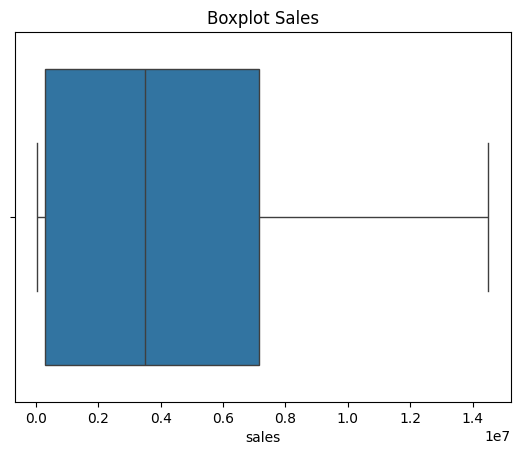

In [30]:
sns.boxplot(x=df["sales"])
plt.title("Boxplot Sales")
plt.show()

In [36]:
df["order_date"] = pd.to_datetime(df["order_date"])
df_trend = df.groupby(df["order_date"].dt.to_period("M"))["sales"].sum()
df_trend.head()

,sales
order_date,
2023-01,46250000


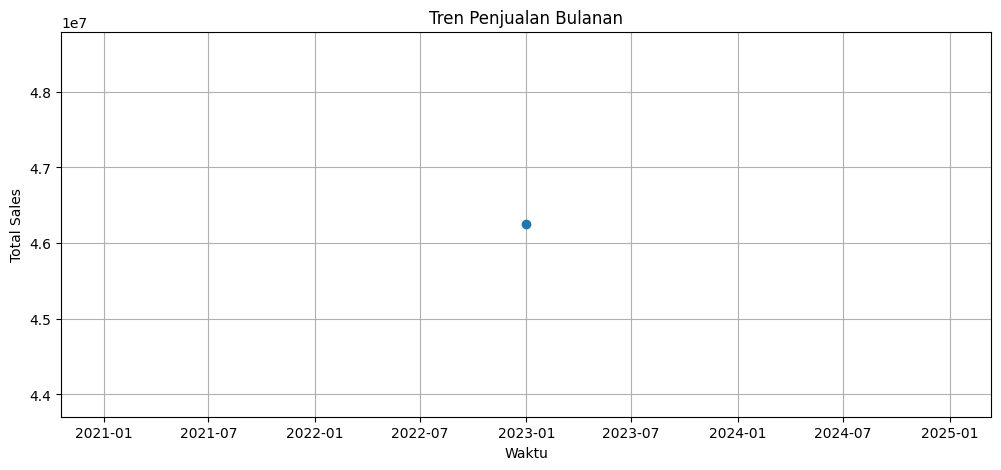

In [49]:
plt.figure(figsize=(12,5))
plt.plot(df_trend, marker='o')
plt.title("Tren Penjualan Bulanan")
plt.xlabel("Waktu")
plt.ylabel("Total Sales")
plt.grid()
plt.show()

<Axes: title={'center': 'Tren Profit Bulanan'}, xlabel='order_date'>

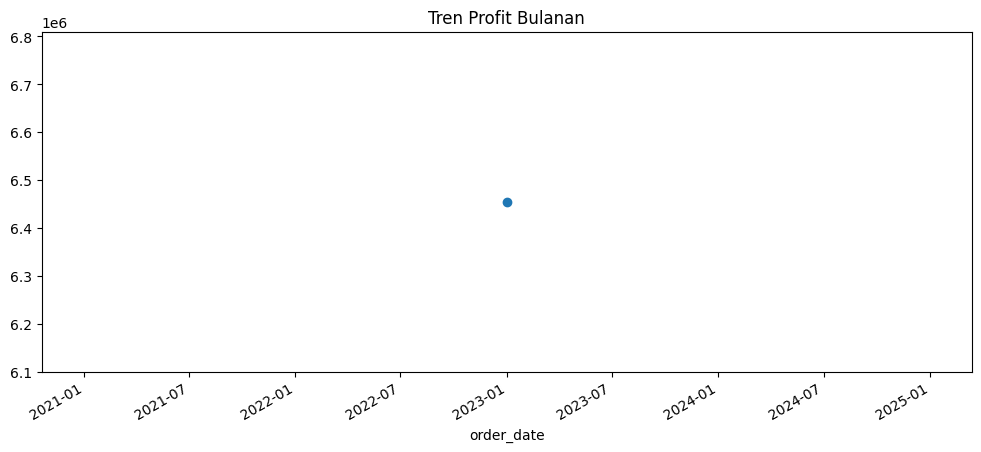

In [52]:
profit_trend = df.groupby(df["order_date"].dt.to_period("M"))["profit"].sum()
profit_trend.index = profit_trend.index.to_timestamp()
profit_trend.plot(figsize=(12,5), title="Tren Profit Bulanan", marker='o')

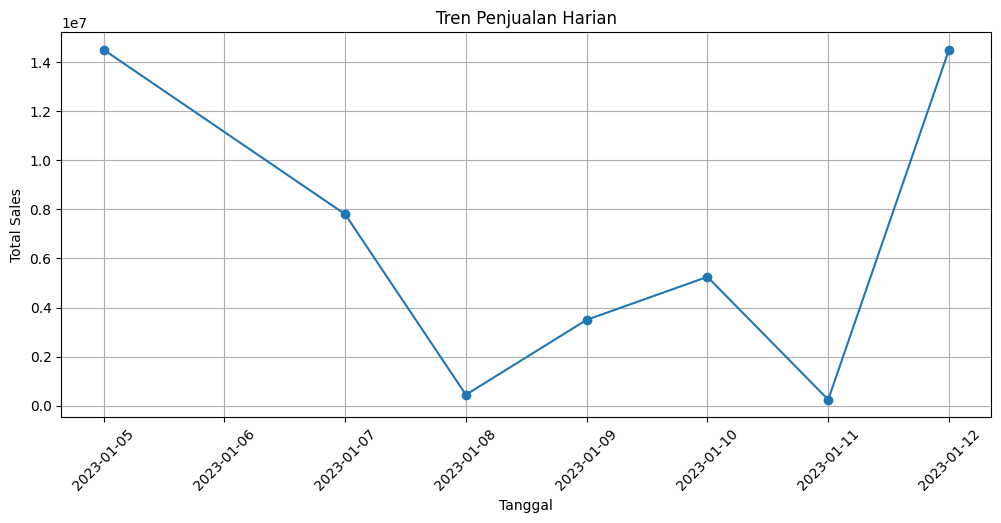

In [50]:
daily_trend = df.groupby(
    df["order_date"].dt.to_period("D")
)["sales"].sum()

daily_trend.index = daily_trend.index.to_timestamp()

plt.figure(figsize=(12,5))

plt.plot(
    daily_trend.index,
    daily_trend.values,
    marker='o'
)

plt.title("Tren Penjualan Harian")

plt.xlabel("Tanggal")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid()

plt.show()